# Tree-Based Return-Risk Model Comparison

## Notebook purpose

This notebook trains and evaluates three tree-based models:

1. Random Forest
2. XGBoost
3. CatBoost

In [17]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from catboost import CatBoostClassifier
from sklearn.compose import ColumnTransformer
from lightgbm import LGBMClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    average_precision_score,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBClassifier

pd.set_option("display.max_columns", 150)
pd.set_option("display.float_format", "{:,.4f}".format)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

RANDOM_SEED = 42

CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"

print(f"Project root: {PROJECT_ROOT}")
print(f"Processed-data directory: {PROCESSED_DIR}")

Project root: C:\Users\Victus\OneDrive\Desktop\E-Commerce-Sales-Analytics
Processed-data directory: C:\Users\Victus\OneDrive\Desktop\E-Commerce-Sales-Analytics\data\processed


# Load Final Training Dataset

In [18]:
training_df = pd.read_csv(
    PROCESSED_DIR / "return_risk_training_data.csv"
)

training_df["order_timestamp"] = pd.to_datetime(
    training_df["order_timestamp"],
    errors="coerce"
)

print(f"Rows: {len(training_df):,}")
print(f"Columns: {training_df.shape[1]:,}")
print(
    "Date range: "
    f"{training_df['order_timestamp'].min()} to "
    f"{training_df['order_timestamp'].max()}"
)

Rows: 123,021
Columns: 55
Date range: 2021-01-01 00:01:30 to 2025-12-31 23:58:53


# Validate Target And Leakage Safety

In [19]:
forbidden_columns = [
    "order_status",
    "return_status",
    "return_reason",
    "delivery_days",
    "delivery_status",
    "customer_rating",
    "review_sentiment",
    "customer_review",
    "payment_status",
    "loyalty_points_earned",
    "loyalty_points_redeemed",
    "estimated_delivery_days",
]

present_forbidden_columns = [
    column
    for column in forbidden_columns
    if column in training_df.columns
]

assert set(training_df["return_label"].unique()) == {0, 1}
assert len(present_forbidden_columns) == 0, (
    f"Leakage columns found: {present_forbidden_columns}"
)

print("Target and leakage validation passed.")
print(
    "Overall return rate: "
    f"{training_df['return_label'].mean() * 100:.2f}%"
)

Target and leakage validation passed.
Overall return rate: 7.69%


# Create Chronological Train, Validation, And Test Sets

In [20]:
train_end_date = pd.Timestamp("2024-12-31 23:59:59")
validation_start_date = pd.Timestamp("2025-01-01")
validation_end_date = pd.Timestamp("2025-06-30 23:59:59")
test_start_date = pd.Timestamp("2025-07-01")
test_end_date = pd.Timestamp("2025-12-31 23:59:59")

train_df = training_df[
    training_df["order_timestamp"] <= train_end_date
].copy()

validation_df = training_df[
    (training_df["order_timestamp"] >= validation_start_date)
    & (training_df["order_timestamp"] <= validation_end_date)
].copy()

test_holdout_df = training_df[
    (training_df["order_timestamp"] >= test_start_date)
    & (training_df["order_timestamp"] <= test_end_date)
].copy()

split_summary = pd.DataFrame([
    {
        "split": "Train",
        "rows": len(train_df),
        "start_date": train_df["order_timestamp"].min(),
        "end_date": train_df["order_timestamp"].max(),
        "return_rate_percent": train_df["return_label"].mean() * 100,
    },
    {
        "split": "Validation",
        "rows": len(validation_df),
        "start_date": validation_df["order_timestamp"].min(),
        "end_date": validation_df["order_timestamp"].max(),
        "return_rate_percent": validation_df["return_label"].mean() * 100,
    },
    {
        "split": "Untouched test holdout",
        "rows": len(test_holdout_df),
        "start_date": test_holdout_df["order_timestamp"].min(),
        "end_date": test_holdout_df["order_timestamp"].max(),
        "return_rate_percent": np.nan,
    },
])

display(split_summary)

assert len(train_df) > 0
assert len(validation_df) > 0
assert len(test_holdout_df) > 0

,split,rows,start_date,end_date,return_rate_percent
0,Train,98376,2021-01-01 00:01:30,2024-12-31 23:59:06,7.6136
1,Validation,10666,2025-01-01 00:15:26,2025-06-30 23:38:51,8.3443
2,Untouched test holdout,13979,2025-07-01 00:02:13,2025-12-31 23:58:53,NaN


# Select Target And Model Features

In [21]:
target_column = "return_label"

non_feature_columns = [
    "order_id",
    "customer_id",
    "order_timestamp",
    "order_timestamp_customer",
    target_column,
]

feature_columns = [
    column
    for column in training_df.columns
    if column not in non_feature_columns
]

X_train = train_df[feature_columns].copy()
y_train = train_df[target_column].copy()

X_validation = validation_df[feature_columns].copy()
y_validation = validation_df[target_column].copy()

categorical_columns = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numeric_columns = [
    column
    for column in feature_columns
    if column not in categorical_columns
]

print(f"Total features: {len(feature_columns)}")
print(f"Categorical features: {len(categorical_columns)}")
print(f"Numeric features: {len(numeric_columns)}")
X_train.head()

Total features: 50
Categorical features: 14
Numeric features: 36


,order_month,order_day_of_week,order_hour,order_quarter,sales_channel,payment_method,currency,shipping_method,warehouse,marketing_channel,campaign_name,coupon_code,prior_order_count,prior_total_spend,prior_total_discount,prior_return_count,prior_average_order_value,prior_return_rate,prior_average_discount,days_since_previous_order,is_first_order,customer_age,gender,customer_segment,customer_state,customer_country,region,customer_acquisition_cost,item_count,unique_product_count,total_quantity,category_count,subcategory_count,brand_count,supplier_count,total_gross_sales,total_tax_amount,total_shipping_cost,total_item_net_sales,total_item_product_cost,total_item_profit,minimum_item_unit_price,maximum_item_unit_price,average_item_unit_price,minimum_product_rating,maximum_product_rating,average_product_rating,average_quantity_per_item,order_profit_margin_percentage,dominant_product_category
0,11,0,16,4,Mobile App,Digital Wallet,USD,Standard,WH-003,Direct,Default_Campaign,Unknown,5,"6,532.0100",888.7100,0,"1,306.4020",0.0000,177.7420,312.1238,0,55,Male,Consumer,Texas,USA,South,73.0600,2,2,5,2,2,2,2,"1,350.1900",61.0700,12.0300,945.4000,588.3300,345.0400,244.4000,287.1300,265.7650,3.0000,4.8000,3.9000,2.5000,36.4967,Fashion
2,7,0,14,3,Mobile App,Cash on Delivery,USD,Express,WH-015,YouTube,Unknown,Unknown,0,0.0000,0.0000,0,NaN,NaN,NaN,NaN,1,69,Female,Premium,New York,USA,East,52.0200,2,2,5,2,2,2,2,522.8100,29.7900,13.0500,468.3500,257.7300,197.5700,6.3100,251.9400,129.1250,2.8000,3.0000,2.9000,2.5000,42.1843,Health & Wellness
3,1,5,7,1,Social Media,Debit Card,USD,Express,WH-010,Email Marketing,Unknown,Unknown,4,"2,931.9700",525.4400,1,732.9925,0.2500,131.3600,23.7778,0,65,Male,Consumer,North Carolina,USA,South,65.9100,2,2,2,2,2,2,2,544.6200,34.3900,20.8500,546.5200,277.8400,247.8300,264.4300,280.1900,272.3100,3.8000,4.6000,4.2000,1.0000,45.3469,Automotive
4,5,4,9,2,Social Media,Digital Wallet,INR,Standard,WH-013,Direct,Unknown,Unknown,0,0.0000,0.0000,0,NaN,NaN,NaN,NaN,1,34,Female,Consumer,Gujarat,India,West,66.2600,3,3,6,3,3,3,3,"2,474.5200",421.3500,23.0300,"2,785.2700","1,231.8800","1,530.3600",62.2600,587.1800,237.6600,2.9000,4.2000,3.7000,2.0000,54.9448,Home Appliances
5,5,0,2,2,Mobile App,Credit Card,USD,Economy,WH-006,Direct,Unknown,Unknown,0,0.0000,0.0000,0,NaN,NaN,NaN,NaN,1,61,Female,Consumer,Texas,USA,South,35.1400,5,5,9,5,5,5,3,"1,661.1400",106.5400,63.2700,"1,691.8700",757.6700,870.9300,75.1700,657.0500,269.3560,3.3000,4.8000,4.2200,1.8000,51.4774,Home Appliances


# Create Preprocessing For Random Forest And XGBoost


In [22]:
tree_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
            ]),
            numeric_columns,
        ),
        (
            "categorical",
            Pipeline([
                (
                    "imputer",
                    SimpleImputer(
                        strategy="constant",
                        fill_value="Unknown"
                    ),
                ),
                (
                    "encoder",
                    OneHotEncoder(
                        handle_unknown="ignore"
                    ),
                ),
            ]),
            categorical_columns,
        ),
    ]
)

# Prepare CatBoost Input Data


In [23]:
def prepare_catboost_data(dataframe, categorical_columns):
    prepared_df = dataframe.copy()

    prepared_df = prepared_df.replace(
        [np.inf, -np.inf],
        np.nan
    )

    for column in categorical_columns:
        prepared_df[column] = (
            prepared_df[column]
            .fillna("Unknown")
            .astype(str)
        )

    return prepared_df


X_train_catboost = prepare_catboost_data(
    X_train,
    categorical_columns
)

X_validation_catboost = prepare_catboost_data(
    X_validation,
    categorical_columns
)

# Define Tree-Based Models

In [24]:
positive_class_weight = (
    (y_train == 0).sum() / (y_train == 1).sum()
)

lightgbm_model = Pipeline([
    ("preprocessor", tree_preprocessor),
    (
        "model",
        LGBMClassifier(
            objective="binary",
            n_estimators=500,
            learning_rate=0.03,
            num_leaves=31,
            max_depth=-1,
            min_child_samples=50,
            subsample=0.8,
            subsample_freq=1,
            colsample_bytree=0.8,
            reg_lambda=1.0,
            scale_pos_weight=positive_class_weight,
            random_state=RANDOM_SEED,
            n_jobs=-1,
            verbosity=-1,
        ),
    ),
])

xgboost_model = Pipeline([
    ("preprocessor", tree_preprocessor),
    (
        "model",
        XGBClassifier(
            n_estimators=400,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            min_child_weight=5,
            reg_lambda=1.0,
            scale_pos_weight=positive_class_weight,
            objective="binary:logistic",
            eval_metric="aucpr",
            random_state=RANDOM_SEED,
            n_jobs=-1,
        ),
    ),
])

catboost_model = CatBoostClassifier(
    iterations=500,
    depth=7,
    learning_rate=0.05,
    loss_function="Logloss",
    eval_metric="PRAUC",
    class_weights=[1.0, positive_class_weight],
    random_seed=RANDOM_SEED,
    verbose=100,
    allow_writing_files=False,
)

# Create A Reusable Validation Function

In [25]:
def evaluate_model_on_validation(
    model_name,
    model,
    X_train,
    y_train,
    X_validation,
    y_validation,
    fit_parameters=None,
):
    if fit_parameters is None:
        fit_parameters = {}

    model.fit(
        X_train,
        y_train,
        **fit_parameters
    )

    validation_probabilities = model.predict_proba(
        X_validation
    )[:, 1]

    threshold_rows = []

    for threshold in np.arange(0.05, 0.96, 0.05):
        validation_predictions = (
            validation_probabilities >= threshold
        ).astype(int)

        threshold_rows.append({
            "threshold": round(float(threshold), 2),
            "precision": precision_score(
                y_validation,
                validation_predictions,
                zero_division=0,
            ),
            "recall": recall_score(
                y_validation,
                validation_predictions,
                zero_division=0,
            ),
            "f1_score": f1_score(
                y_validation,
                validation_predictions,
                zero_division=0,
            ),
        })

    threshold_results_df = pd.DataFrame(threshold_rows)

    best_threshold_row = threshold_results_df.loc[
        threshold_results_df["f1_score"].idxmax()
    ]

    best_threshold = best_threshold_row["threshold"]

    final_predictions = (
        validation_probabilities >= best_threshold
    ).astype(int)

    model_result = {
        "model": model_name,
        "pr_auc": average_precision_score(
            y_validation,
            validation_probabilities,
        ),
        "roc_auc": roc_auc_score(
            y_validation,
            validation_probabilities,
        ),
        "best_threshold": best_threshold,
        "precision": precision_score(
            y_validation,
            final_predictions,
            zero_division=0,
        ),
        "recall": recall_score(
            y_validation,
            final_predictions,
            zero_division=0,
        ),
        "f1_score": f1_score(
            y_validation,
            final_predictions,
            zero_division=0,
        ),
    }

    return (
        model,
        validation_probabilities,
        final_predictions,
        threshold_results_df,
        model_result,
    )

# Train And Evaluate LightGBM

In [26]:
(
    trained_lightgbm_model,
    lightgbm_validation_probabilities,
    lightgbm_validation_predictions,
    lightgbm_threshold_results,
    lightgbm_result,
) = evaluate_model_on_validation(
    model_name="LightGBM",
    model=lightgbm_model,
    X_train=X_train,
    y_train=y_train,
    X_validation=X_validation,
    y_validation=y_validation,
)

display(pd.DataFrame([lightgbm_result]))
display(lightgbm_threshold_results)

,model,pr_auc,roc_auc,best_threshold,precision,recall,f1_score
0,LightGBM,0.6264,0.9342,0.7000,0.6048,0.6225,0.6135


,threshold,precision,recall,f1_score
0,0.0500,0.0985,0.9921,0.1792
1,0.1000,0.1182,0.9865,0.2112
2,0.1500,0.1382,0.9854,0.2424
3,0.2000,0.1583,0.9798,0.2725
4,0.2500,0.1805,0.9753,0.3046
5,0.3000,0.2027,0.9663,0.3352
6,0.3500,0.2307,0.9562,0.3718
7,0.4000,0.2625,0.9404,0.4105
8,0.4500,0.2966,0.9225,0.4489
9,0.5000,0.3392,0.8944,0.4918


# Train And Evaluate XGBoost

In [27]:
(
    trained_xgboost_model,
    xgboost_validation_probabilities,
    xgboost_validation_predictions,
    xgboost_threshold_results,
    xgboost_result,
) = evaluate_model_on_validation(
    model_name="XGBoost",
    model=xgboost_model,
    X_train=X_train,
    y_train=y_train,
    X_validation=X_validation,
    y_validation=y_validation,
)

display(pd.DataFrame([xgboost_result]))
display(xgboost_threshold_results)

,model,pr_auc,roc_auc,best_threshold,precision,recall,f1_score
0,XGBoost,0.6241,0.9291,0.6500,0.5969,0.6124,0.6045


,threshold,precision,recall,f1_score
0,0.0500,0.0981,0.9910,0.1785
1,0.1000,0.1170,0.9876,0.2092
2,0.1500,0.1388,0.9798,0.2432
3,0.2000,0.1644,0.9742,0.2814
4,0.2500,0.1915,0.9629,0.3194
5,0.3000,0.2239,0.9528,0.3626
6,0.3500,0.2603,0.9382,0.4075
7,0.4000,0.3007,0.9101,0.4520
8,0.4500,0.3492,0.8798,0.5000
9,0.5000,0.3951,0.8292,0.5352


# Train And Evaluate CatBoost

In [28]:
(
    trained_catboost_model,
    catboost_validation_probabilities,
    catboost_validation_predictions,
    catboost_threshold_results,
    catboost_result,
) = evaluate_model_on_validation(
    model_name="CatBoost",
    model=catboost_model,
    X_train=X_train_catboost,
    y_train=y_train,
    X_validation=X_validation_catboost,
    y_validation=y_validation,
    fit_parameters={
        "cat_features": categorical_columns
    },
)

display(pd.DataFrame([catboost_result]))
display(catboost_threshold_results)

0:	learn: 0.7608613	total: 178ms	remaining: 1m 28s
100:	learn: 0.8532027	total: 18.2s	remaining: 1m 11s
200:	learn: 0.8951968	total: 34.6s	remaining: 51.5s
300:	learn: 0.9389590	total: 50.9s	remaining: 33.6s
400:	learn: 0.9639161	total: 1m 6s	remaining: 16.5s
499:	learn: 0.9759883	total: 1m 21s	remaining: 0us


,model,pr_auc,roc_auc,best_threshold,precision,recall,f1_score
0,CatBoost,0.5932,0.9235,0.6500,0.4996,0.6629,0.5698


,threshold,precision,recall,f1_score
0,0.0500,0.0937,0.9933,0.1713
1,0.1000,0.1080,0.9921,0.1948
2,0.1500,0.1233,0.9899,0.2193
3,0.2000,0.1388,0.9820,0.2433
4,0.2500,0.1576,0.9764,0.2714
5,0.3000,0.1789,0.9674,0.3020
6,0.3500,0.2047,0.9562,0.3372
7,0.4000,0.2371,0.9427,0.3790
8,0.4500,0.2747,0.9202,0.4231
9,0.5000,0.3201,0.8854,0.4702


# Compare Tree-Based Model Validation Results

In [29]:
tree_results_df = pd.DataFrame([
    lightgbm_result,
    xgboost_result,
    catboost_result,
]).sort_values(
    "pr_auc",
    ascending=False
)

display(tree_results_df)

,model,pr_auc,roc_auc,best_threshold,precision,recall,f1_score
0,LightGBM,0.6264,0.9342,0.7000,0.6048,0.6225,0.6135
1,XGBoost,0.6241,0.9291,0.6500,0.5969,0.6124,0.6045
2,CatBoost,0.5932,0.9235,0.6500,0.4996,0.6629,0.5698


# Visualize Validation Confusion Matrices

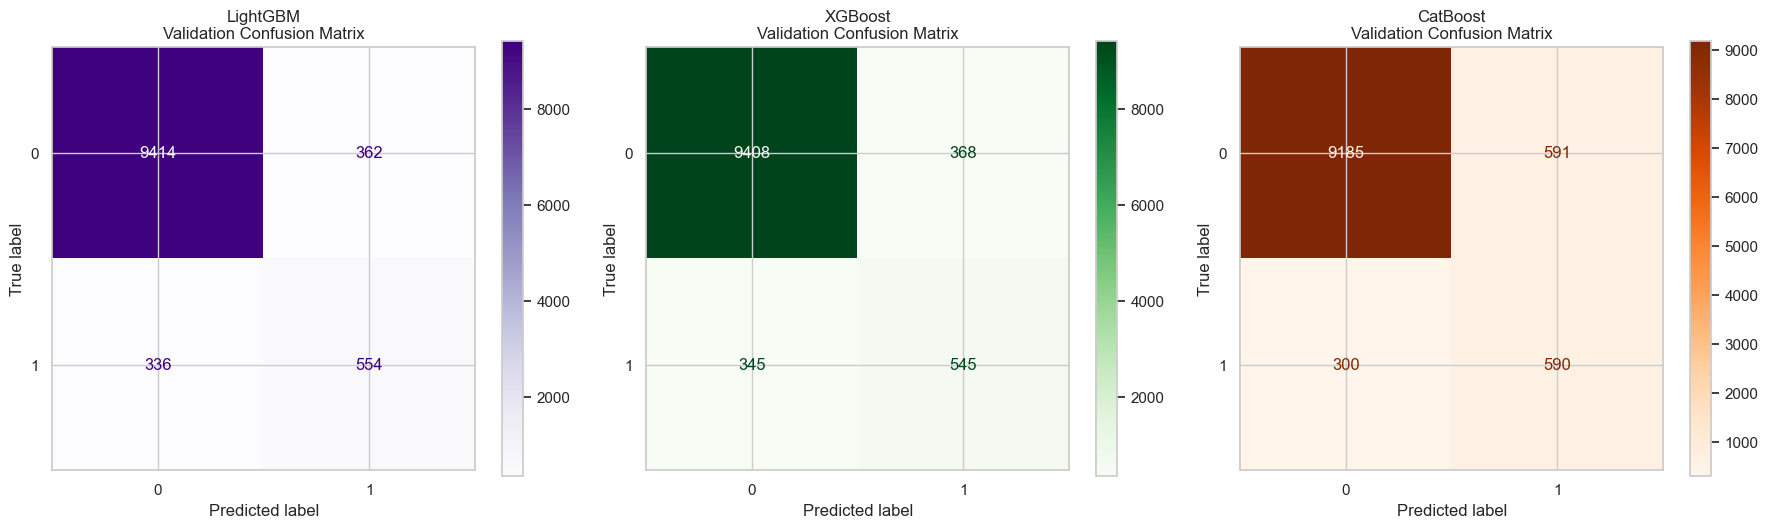

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

confusion_matrix_data = [
    (
        "LightGBM",
        lightgbm_validation_predictions,
        "Purples",
    ),
    (
        "XGBoost",
        xgboost_validation_predictions,
        "Greens",
    ),
    (
        "CatBoost",
        catboost_validation_predictions,
        "Oranges",
    ),
]

for axis, (model_name, predictions, color) in zip(
    axes,
    confusion_matrix_data
):
    ConfusionMatrixDisplay.from_predictions(
        y_validation,
        predictions,
        ax=axis,
        cmap=color,
    )
    axis.set_title(
        f"{model_name}\nValidation Confusion Matrix"
    )

plt.tight_layout()
plt.show()

# Visualize Validation Precision-Recall Curves

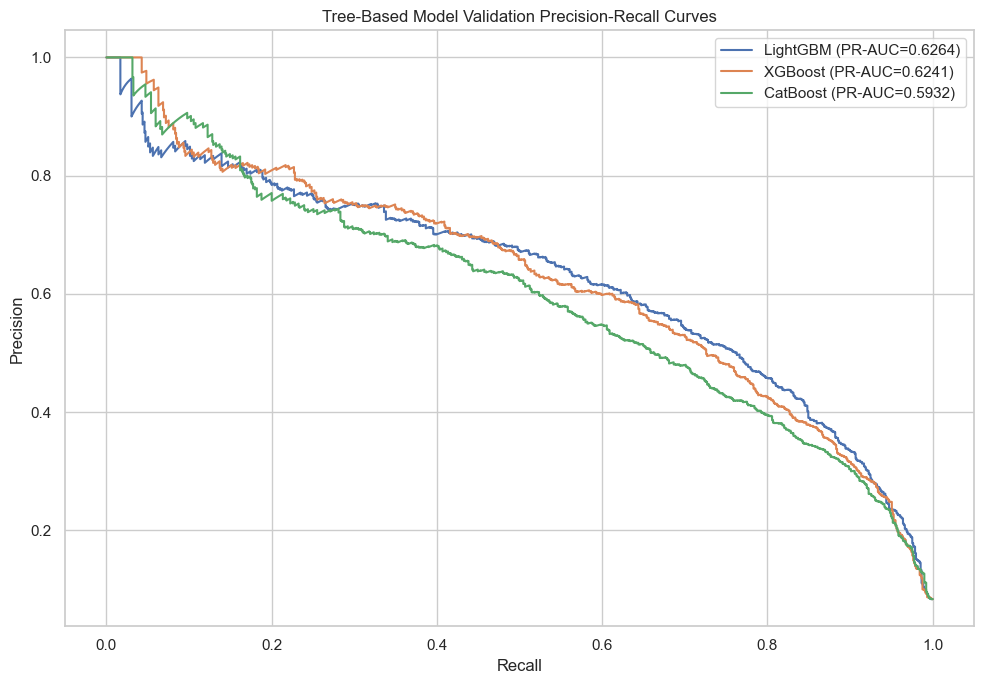

In [31]:
lightgbm_precision, lightgbm_recall, _ = precision_recall_curve(
    y_validation,
    lightgbm_validation_probabilities,
)

xgboost_precision, xgboost_recall, _ = precision_recall_curve(
    y_validation,
    xgboost_validation_probabilities,
)

catboost_precision, catboost_recall, _ = precision_recall_curve(
    y_validation,
    catboost_validation_probabilities,
)

plt.figure(figsize=(10, 7))

plt.plot(
    lightgbm_recall,
    lightgbm_precision,
    label=(
        "LightGBM "
        f"(PR-AUC={lightgbm_result['pr_auc']:.4f})"
    ),
)

plt.plot(
    xgboost_recall,
    xgboost_precision,
    label=(
        "XGBoost "
        f"(PR-AUC={xgboost_result['pr_auc']:.4f})"
    ),
)

plt.plot(
    catboost_recall,
    catboost_precision,
    label=(
        "CatBoost "
        f"(PR-AUC={catboost_result['pr_auc']:.4f})"
    ),
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Tree-Based Model Validation Precision-Recall Curves")
plt.legend()
plt.tight_layout()
plt.show()

# Save Tree-Model Validation Results


In [32]:
tree_results_path = (
    PROCESSED_DIR / "tree_model_validation_results.csv"
)

tree_results_df.to_csv(
    tree_results_path,
    index=False,
)

print(f"Saved tree-model results to: {tree_results_path}")

Saved tree-model results to: C:\Users\Victus\OneDrive\Desktop\E-Commerce-Sales-Analytics\data\processed\tree_model_validation_results.csv
